In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
DATA_PATH = os.path.join("..", "data", "raw", "demand_forecasting.csv")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
print("Shape:", df.shape)
df.head()

Shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
# Date-based features
df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["day_of_year"] = df["Date"].dt.dayofyear
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Price-related features
df["price_diff_vs_competitor"] = df["Price"] - df["Competitor Pricing"]
df["discount_pct"] = df["Discount"] / (df["Price"] + 1e-5)

# Encode categoricals
categorical_cols = ["Store ID", "Product ID", "Category", "Region", "Weather Condition", "Seasonality"]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    encoders[col] = le

feature_cols = [
    "Store ID_enc", "Product ID_enc", "Category_enc", "Region_enc",
    "Inventory Level", "Price", "Discount", "Weather Condition_enc",
    "Promotion", "Competitor Pricing", "Seasonality_enc", "Epidemic",
    "day_of_week", "month", "day_of_year", "is_weekend",
    "price_diff_vs_competitor", "discount_pct",
]

X = df[feature_cols]
y = df["Demand"]
print(f"Features: {len(feature_cols)}, Rows: {len(X)}")

Features: 18, Rows: 76000


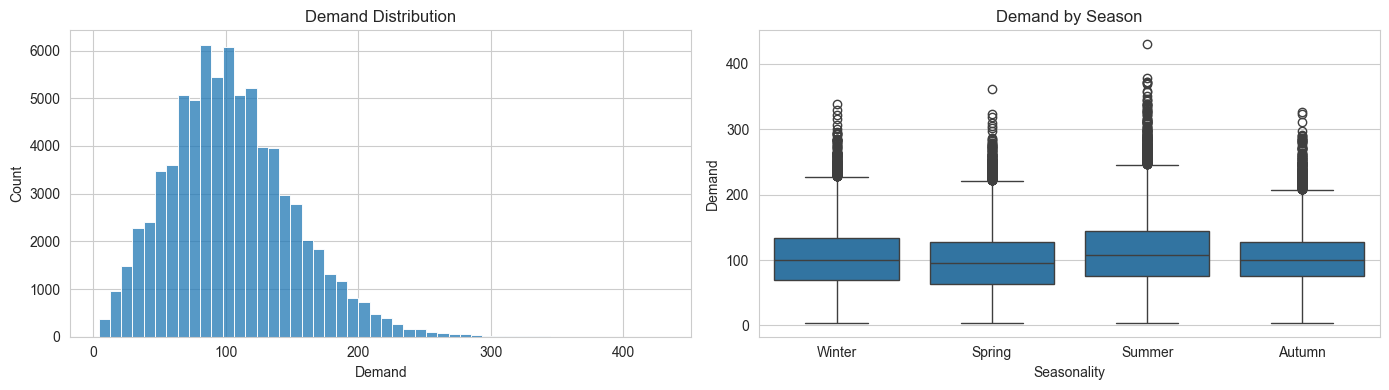

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Demand"], bins=50, ax=axes[0])
axes[0].set_title("Demand Distribution")

sns.boxplot(data=df, x="Seasonality", y="Demand", ax=axes[1])
axes[1].set_title("Demand by Season")

plt.tight_layout()
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 60800, Test size: 15200


In [6]:
def evaluate_model(name, model, X_test, y_test):
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.4f}")
    return {"name": name, "rmse": rmse, "mae": mae, "r2": r2, "model": model, "predictions": predictions}

results = []

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate_model("Linear Regression", lr, X_test, y_test))

Linear Regression: RMSE=40.59, MAE=31.95, R²=0.2540


In [8]:
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model("Random Forest", rf, X_test, y_test))

Random Forest: RMSE=27.12, MAE=19.68, R²=0.6669


In [9]:
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test))

XGBoost: RMSE=21.97, MAE=15.62, R²=0.7815


In [10]:
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test))

XGBoost: RMSE=21.97, MAE=15.62, R²=0.7815


               Model       RMSE        MAE        R2
0  Linear Regression  40.588763  31.951120  0.254048
1      Random Forest  27.123000  19.677349  0.666900
2            XGBoost  21.967459  15.619733  0.781496
3            XGBoost  21.967459  15.619733  0.781496


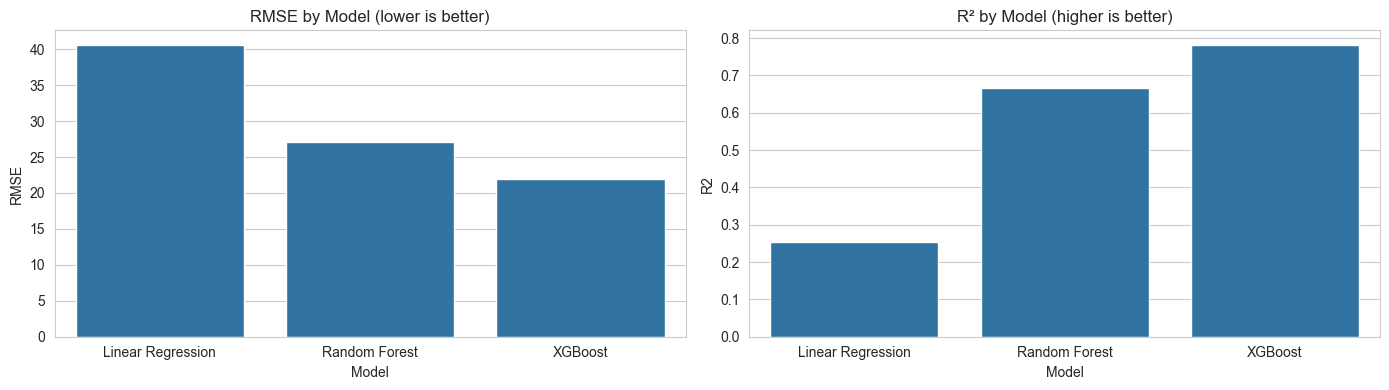

In [11]:
comparison_df = pd.DataFrame([{"Model": r["name"], "RMSE": r["rmse"], "MAE": r["mae"], "R2": r["r2"]} for r in results])
print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=comparison_df, x="Model", y="RMSE", ax=axes[0])
axes[0].set_title("RMSE by Model (lower is better)")
sns.barplot(data=comparison_df, x="Model", y="R2", ax=axes[1])
axes[1].set_title("R² by Model (higher is better)")
plt.tight_layout()
plt.show()

Best model: XGBoost


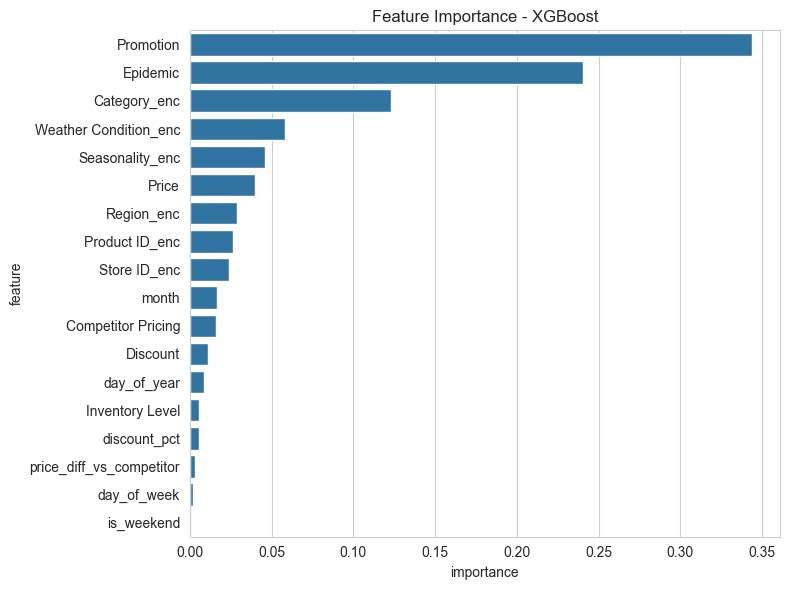

In [12]:
best = min(results, key=lambda r: r["rmse"])
print(f"Best model: {best['name']}")

if hasattr(best["model"], "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": best["model"].feature_importances_
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title(f"Feature Importance - {best['name']}")
    plt.tight_layout()
    plt.show()

In [13]:
model_bundle = {
    "model": best["model"],
    "model_name": best["name"],
    "encoders": encoders,
    "feature_cols": feature_cols,
}
save_path = os.path.join(MODEL_DIR, "demand_forecast_model.pkl")
joblib.dump(model_bundle, save_path)
print(f"Saved best model ({best['name']}) to {save_path}")

Saved best model (XGBoost) to ..\models\demand_forecast_model.pkl
